# RETO 1: Determinación de la población real del destino

En un destino turístico residencial como Torrevieja, la población empadronada no coincide necesariamente con la población realmente presente en cada momento. Por ello, el objetivo de este reto es **estimar o aproximar la población efectiva** y analizar cómo varía a lo largo del tiempo.

## 1. INTRODUCCIÓN

A continuación, se define el marco teórico sobre la población flotante, las fuentes utilizadas para su aproximación y sus limitaciones.

#### A. Definición de la Población Real o Efectiva

En el análisis demográfico y turístico, es crucial distinguir entre diferentes capas de población:

* **Población de Derecho (Empadronada):** Son las personas inscritas oficialmente en el padrón municipal. Es la cifra estática que usa el Estado para asignar recursos, pero en destinos turísticos suele subestimar la realidad. (TENGO EL CENSO DADO POR EL INE DESDE 1996-2025 Y EL CENSO DADO POR LA PEGV DESDE 2002 HASTA 2023 DIVIDIDO EN ENERO Y JULIO)
* **Población Flotante:** Es el conjunto de personas que, sin estar empadronadas, residen temporalmente en el municipio. Incluye turistas de hotel, turistas de segunda residencia, excursionistas y trabajadores de temporada.
* **Población Real (o Efectiva):** Es la suma de la *población empadronada presente* más la *población flotante* en un momento dado. Es la cantidad real de personas que consumen recursos y requieren servicios públicos en el destino.

#### B. Indicadores y Variables de Aproximación

Como no es posible realizar un censo diario, se utilizan **variables proxy** (rastros indirectos que deja el consumo humano):

* **Generación de Residuos Sólidos Urbanos (RSU):** Cantidad de basura recogida. Es uno de los indicadores tradicionales más fiables. (AÚN NO HE CONSEGUIDO ESTOS DATOS)
* **Consumo de Agua Potable y Depuración:** Volumen de agua suministrada a la red o de aguas residuales tratadas. (AÚN NO HE CONSEGUIDO ESTOS DATOS)
* **Consumo de Energía Eléctrica:** Picos de demanda energética residencial. (SOLO TENGO EL NUMERO DE CASAS EN EL AÑO 2021 DEPENDIENDO DE SU CONSUMO ELECTRICO)
* **Big Data de Movilidad:** Conteo de dispositivos móviles conectados a las antenas de telefonía del municipio (TENGO EL EMISOR, EL RECEPTOR Y EL INTERNO INTERPROVINCIAL).
* **Plazas de Alojamiento y Ocupación:** Multiplicación de las camas turísticas y segundas residencias por índices de ocupación (TENGO EL TIPO DE VIVIENDA (1º O 2º RESIDENCIA) PARA LOS AÑOS 2021, 2011, 2001)

#### C. Supuestos de Partida

Toda estimación basada en variables proxy requiere asumir ciertas hipótesis:

* **Estabilidad del consumo per cápita:** Suponemos que cada individuo genera una cantidad media similar de basura o consume una cantidad de agua predecible al día.
* **Correlación lineal:** Asumimos que las variaciones porcentuales en el consumo (ej. aumento del 50% de basura en agosto) equivalen matemáticamente al aumento de la población efectiva.
* **Homogeneidad tecnológica:** Si utilizamos datos móviles, asumimos una penetración casi universal de la telefonía y que un dispositivo equivale a una persona.

#### D. Nivel de Confianza y Limitaciones

El modelo proporciona una estimación estadística, sujeta a las siguientes limitaciones:

* **Estacionalidad del consumo:** Un turista en verano puede consumir más agua (duchas, piscinas) que un residente en invierno. Esto puede sobreestimar la población si no se aplican factores de corrección.
* **Impacto comercial e industrial:** Los consumos y residuos provienen también del sector servicios (HORECA), cuya actividad se dispara en temporada alta.
* **Triangulación:** Para maximizar el nivel de confianza, es imprescindible cruzar varios indicadores (ej. curvas de RSU vs. datos móviles). La convergencia de tendencias valida la robustez de la estimación.

## 2. INFORMACIÓN ENCONTRADA Y PREPARACIÓN DE LOS DATOS

En el apartado anterior se ha establecido el marco teórico y los indicadores 'proxy' necesarios para estimar la población efectiva de Torrevieja. Sin embargo, al trasladar este modelo a la práctica nos enfrentamos a la realidad del análisis de datos en entornos no controlados: la información rara vez se encuentra centralizada, completa o lista para su explotación. Las fuentes disponibles provienen de distintas administraciones, presentan niveles dispares de granularidad (temporal y espacial), formatos heterogéneos y, frecuentemente, ruido o valores ausentes.

Para abordar este reto y garantizar la reproducibilidad del análisis, este apartado documenta exhaustivamente la fase de preparación de datos (Data Preparation). Con el fin de mantener un orden lógico, la información se ha estructurado agrupando los datasets por su naturaleza o temática.

Para cada conjunto de datos (o grupo de datos relacionados), se detallará el siguiente proceso:

* Identificación y origen: Descripción de la fuente, las variables principales y su cobertura.

* Estado inicial y evaluación de calidad: Análisis exploratorio de los datos crudos (raw data), detectando formatos, discrepancias y limitaciones intrínsecas de la fuente.

* Limpieza y transformación (Data Wrangling): Procedimientos aplicados para la normalización, filtrado, tratamiento de valores nulos o atípicos y adecuación de formatos.

* Integración: Decisiones metodológicas para unificar esa información con el resto de las fuentes y construir el conjunto de datos final sobre el que se aplicarán las técnicas de minería.

A continuación, se expone el tratamiento realizado sobre las distintas fuentes recopiladas para la resolución del Reto 1.

#### A. CENSO DE TORREVIEJA

##### 1. Identificación y origen

Para establecer la "población de derecho" —que servirá como línea base estática para estimar posteriormente la población efectiva— se han extraído datos de dos fuentes oficiales:

* **Instituto Nacional de Estadística (INE):** Se ha descargado el padrón continuo por municipios, obteniendo el archivo `censo_1996_2025.csv` con periodicidad anual. Los datos los puedes encontrar en: [Padrón continuo por municipios (INE)](https://www.ine.es/jaxiT3/Tabla.htm?t=2856&L=0)
* **Portal Estadístic de la Generalitat Valenciana (PEGV):** Se han extraído las estimaciones de población, las cuales aportan un valor añadido al ofrecer desagregación semestral (enero y julio). Los datos se han obtenido en tres cortes temporales: `censo_2002_2012_pegv.csv`, `censo_2013_2020_pegv.csv` y `censo_2021_2023_pegv.csv`, y se pueden encontrar en: [Estimaciones de población (PEGV)](https://pegv.gva.es/es/estimaciones-de-poblacion-de-la-comunitat-valenciana)

##### 2. Estado inicial y evaluación de calidad

Al realizar el Análisis Exploratorio de Datos (EDA) sobre las fuentes originales (*raw data*), se detectaron diversas incidencias que requerían tratamiento:

* **Valores nulos históricos (INE):** El dataset del INE presentaba valores vacíos (`NaN`) para el año 1997 en todas las categorías de sexo. Esto responde a una particularidad histórica en la renovación del padrón a nivel nacional en ese ejercicio.
* **Formato numérico problemático (INE):** Los valores absolutos de población empleaban el punto (`.`) como separador de miles (ej. `98.533`). Sin configuración previa, los lenguajes de programación interpretaban estas cifras erróneamente como números decimales.
* **Inconsistencia de esquemas (PEGV):** Mientras que los archivos de 2002-2012 y 2013-2020 compartían la misma estructura, el tercer archivo (2021-2023) modificaba el nombre de una columna clave, denominando `Edad (grupos quinquenales)` a lo que antes era simplemente `Edad`.
* **Solapamiento temporal (PEGV):** Los archivos de la Generalitat se solapaban en los años de corte (2012 y 2021). Al intentar una concatenación directa de los tres CSV, estos años se duplicaban, generando *outliers* artificiales en los que Torrevieja parecía duplicar repentinamente su población (alcanzando cifras de más de 180.000 habitantes).

##### 3. Limpieza y transformación (Data Wrangling)

Para solventar las incidencias y generar un conjunto de datos robusto, se ejecutó el siguiente *pipeline* de limpieza:

**Para los datos del INE:**
* Se forzó la lectura del separador de miles (`thousands='.'`) para garantizar la correcta tipificación a números enteros.
* Se aplicó una **interpolación lineal** agrupando por categoría de sexo para calcular matemáticamente los valores faltantes de 1997, utilizando como anclaje los datos de 1996 y 1998.

**Para los datos de la PEGV:**
* Se armonizó el nombre de la columna `Edad (grupos quinquenales)` en el tercer dataset, renombrándola a `Edad`.
* Tras concatenar los tres archivos, se aplicó una función de eliminación de duplicados (`drop_duplicates`) basada en el subconjunto temporal y demográfico, eliminando así el efecto de solapamiento y corrigiendo los falsos *outliers* de 2012 y 2021.
* Se filtraron los registros para conservar únicamente la foto demográfica del "1 de enero" de cada año.
* Se agruparon y sumaron los habitantes de todos los tramos de edad para obtener el total consolidado, descartando las filas de totales pre-calculados para evitar doble contabilización.

##### 4. Integración y Comparativa

Como resultado final de la transformación, los datos de la PEGV se consolidaron en un único archivo maestro (`censo_pegv_unificado.csv`).

Al cruzar (mediante un *inner join* temporal) la población total resultante de la PEGV con el padrón depurado del INE, se observó que:
1. Durante la década del *boom* inmobiliario (2002-2013), el INE registraba un excedente de hasta 13.000 habitantes respecto a la PEGV, derivado de la no depuración de los padrones municipales de extranjeros.
2. Tras la regularización censal estatal de 2014, ambas fuentes convergen de manera casi idéntica, presentando márgenes de diferencia estadísticamente insignificantes (inferiores al 1%) hasta la actualidad.

Esta convergencia valida la robustez de la base demográfica (*Población de Derecho*), estableciendo unos cimientos fiables sobre los que sumar posteriormente los indicadores de vivienda y turismo para modelar la Población Efectiva.




=== 1. PRIMERAS FILAS DEL DATASET ===


,Municipios,Sexo,Periodo,Total
0,03133 Torrevieja,Total,2025,98533.0
1,03133 Torrevieja,Total,2024,94803.0
2,03133 Torrevieja,Total,2023,89290.0
3,03133 Torrevieja,Total,2022,83547.0
4,03133 Torrevieja,Total,2021,82842.0



=== 2. INFORMACIÓN GENERAL DEL DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Municipios  90 non-null     object 
 1   Sexo        90 non-null     object 
 2   Periodo     90 non-null     int64  
 3   Total       87 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.9+ KB

=== 3. CONTEO DE VALORES NULOS POR COLUMNA ===
Municipios    0
Sexo          0
Periodo       0
Total         3
dtype: int64

Número de filas exactamente iguales (duplicadas): 0

=== 4. ANÁLISIS DE VALORES ÚNICOS POR COLUMNA ===
Columna 'Municipios': 1 valores únicos.
   Valores: ['03133 Torrevieja']
Columna 'Sexo': 3 valores únicos.
   Valores: ['Total' 'Hombres' 'Mujeres']
Columna 'Periodo': 30 valores únicos.
   Valores: [2025 2024 2023 2022 2021 2020 2019 2018 2017 2016 2015 2014 2013 2012
 2011 2010 2009 2008 2007 2006 2005 2004 2003 2

,Municipios,Sexo,Periodo,Total
28,03133 Torrevieja,Total,1997,NaN
58,03133 Torrevieja,Hombres,1997,NaN
88,03133 Torrevieja,Mujeres,1997,NaN



=== 6. COMPROBACIÓN POST-LIMPIEZA ===
Nulos restantes en 'Total': 0
Archivo limpio guardado correctamente en DATASETS MODIFICADOS


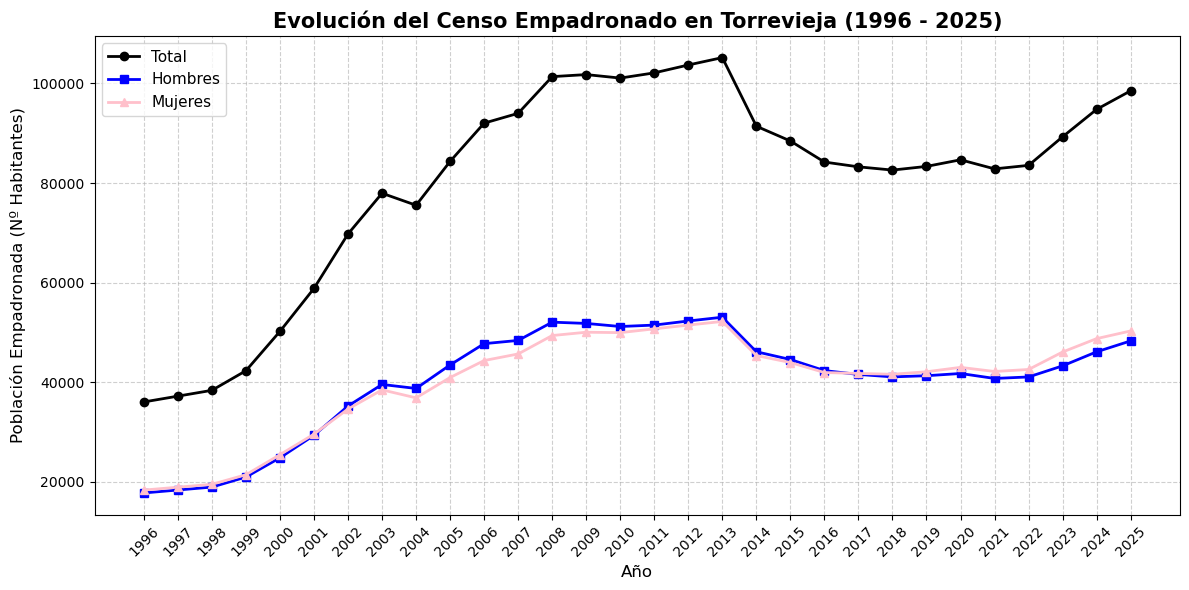

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# =========================================================================
# 1. LECTURA Y CARGA DE DATOS
# =========================================================================

ruta_censo_ine = r'C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES\censo_1996_2025_ine.csv'

df_censo_ine = pd.read_csv(ruta_censo_ine, sep=';', encoding='latin1', thousands='.')

# =========================================================================
# 2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# =========================================================================
print("=== 1. PRIMERAS FILAS DEL DATASET ===")
display(df_censo_ine.head())

print("\n=== 2. INFORMACIÓN GENERAL DEL DATASET ===")
df_censo_ine.info()

print("\n=== 3. CONTEO DE VALORES NULOS POR COLUMNA ===")
print(df_censo_ine.isnull().sum())

print(f"\nNúmero de filas exactamente iguales (duplicadas): {df_censo_ine.duplicated().sum()}\n")

print("=== 4. ANÁLISIS DE VALORES ÚNICOS POR COLUMNA ===")
for col in df_censo_ine.columns:
    num_unicos = df_censo_ine[col].nunique()
    print(f"Columna '{col}': {num_unicos} valores únicos.")
    if num_unicos < 50:
        print(f"   Valores: {df_censo_ine[col].unique()}")

filas_nulas = df_censo_ine[df_censo_ine['Total'].isnull()]
print("\n=== 5. FILAS CON EL TOTAL SIN RELLENAR (EL HUECO DE 1997) ===")
display(filas_nulas)

# =========================================================================
# 3. LIMPIEZA DE DATOS Y RELLENO DE NULOS (1997)
# =========================================================================

df_censo_ine = df_censo_ine.sort_values(by=['Sexo', 'Periodo']).reset_index(drop=True)

df_censo_ine['Total'] = df_censo_ine.groupby('Sexo')['Total'].transform(lambda x: x.interpolate(method='linear'))

df_censo_ine['Total'] = df_censo_ine['Total'].round().astype(int)

print("\n=== 6. COMPROBACIÓN POST-LIMPIEZA ===")
print("Nulos restantes en 'Total':", df_censo_ine['Total'].isnull().sum())

# =========================================================================
# 3.5 GUARDADO DEL CSV LIMPIO (AÑADIDO)
# =========================================================================

ruta_salida = r'C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS MODIFICADOS'

os.makedirs(ruta_salida, exist_ok=True)

df_censo_ine.to_csv(os.path.join(ruta_salida, 'censo_ine_limpio.csv'),
                    index=False,
                    sep=';',
                    encoding='utf-8-sig')

print("Archivo limpio guardado correctamente en DATASETS MODIFICADOS")

# =========================================================================
# 4. PREPARACIÓN DE DATOS PARA LA GRÁFICA
# =========================================================================

df_total = df_censo_ine[df_censo_ine['Sexo'] == 'Total']
df_hombres = df_censo_ine[df_censo_ine['Sexo'] == 'Hombres']
df_mujeres = df_censo_ine[df_censo_ine['Sexo'] == 'Mujeres']

# =========================================================================
# 5. CREACIÓN Y DISEÑO DE LA GRÁFICA
# =========================================================================

plt.figure(figsize=(12, 6))

plt.plot(df_total['Periodo'], df_total['Total'], color='black', label='Total', marker='o', linewidth=2)
plt.plot(df_hombres['Periodo'], df_hombres['Total'], color='blue', label='Hombres', marker='s', linewidth=2)
plt.plot(df_mujeres['Periodo'], df_mujeres['Total'], color='pink', label='Mujeres', marker='^', linewidth=2)

plt.title('Evolución del Censo Empadronado en Torrevieja (1996 - 2025)', fontsize=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Población Empadronada (Nº Habitantes)', fontsize=12)

plt.xticks(df_total['Periodo'], rotation=45)

plt.legend(fontsize=11)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()


 EDA DEL DATASET: CENSO 2002-2012

1. Nombre de las columnas:
['Periodo', 'Municipios', 'Sexo', 'Edad', 'Valor']

2. Tipos de datos y nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Periodo     660 non-null    object
 1   Municipios  660 non-null    object
 2   Sexo        660 non-null    object
 3   Edad        660 non-null    object
 4   Valor       660 non-null    int64 
dtypes: int64(1), object(4)
memory usage: 25.9+ KB

3. Primeras 3 filas:


,Periodo,Municipios,Sexo,Edad,Valor
0,1 de enero de 2002,03133 - Torrevieja,Ambos sexos,De 0 a 4 años,2363
1,1 de enero de 2002,03133 - Torrevieja,Ambos sexos,De 10 a 14 años,2502
2,1 de enero de 2002,03133 - Torrevieja,Ambos sexos,De 15 a 19 años,2595



 EDA DEL DATASET: CENSO 2013-2020

1. Nombre de las columnas:
['Periodo', 'Municipios', 'Sexo', 'Edad', 'Valor']

2. Tipos de datos y nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Periodo     1197 non-null   object
 1   Municipios  1197 non-null   object
 2   Sexo        1197 non-null   object
 3   Edad        1197 non-null   object
 4   Valor       1197 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 46.9+ KB

3. Primeras 3 filas:


,Periodo,Municipios,Sexo,Edad,Valor
0,1 de enero de 2012,03133 - Torrevieja,Ambos sexos,95 y más años,82
1,1 de enero de 2012,03133 - Torrevieja,Ambos sexos,De 0 a 4 años,3858
2,1 de enero de 2012,03133 - Torrevieja,Ambos sexos,De 10 a 14 años,3665



 EDA DEL DATASET: CENSO 2021-2023

1. Nombre de las columnas:
['Periodo', 'Municipios', 'Sexo', 'Edad (grupos quinquenales)', 'Valor']

2. Tipos de datos y nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Periodo                     420 non-null    object
 1   Municipios                  420 non-null    object
 2   Sexo                        420 non-null    object
 3   Edad (grupos quinquenales)  420 non-null    object
 4   Valor                       420 non-null    int64 
dtypes: int64(1), object(4)
memory usage: 16.5+ KB

3. Primeras 3 filas:


,Periodo,Municipios,Sexo,Edad (grupos quinquenales),Valor
0,1 de enero de 2021,03133 - Torrevieja,Ambos sexos,De 0 a 4 años,3158
1,1 de enero de 2021,03133 - Torrevieja,Ambos sexos,De 10 a 14 años,4353
2,1 de enero de 2021,03133 - Torrevieja,Ambos sexos,De 15 a 19 años,3956



!!! CONCLUSIÓN DEL EDA INDIVIDUAL !!!
-> Los CSV 1 y 2 tienen la columna 'Edad'.
-> El CSV 3 tiene la columna 'Edad (grupos quinquenales)'.
-> Para poder unirlos, PRIMERO debemos renombrar esa columna del CSV 3.

¡Fusión completada! Archivo 'censo_pegv_unificado.csv' limpio de duplicados y creado con éxito.



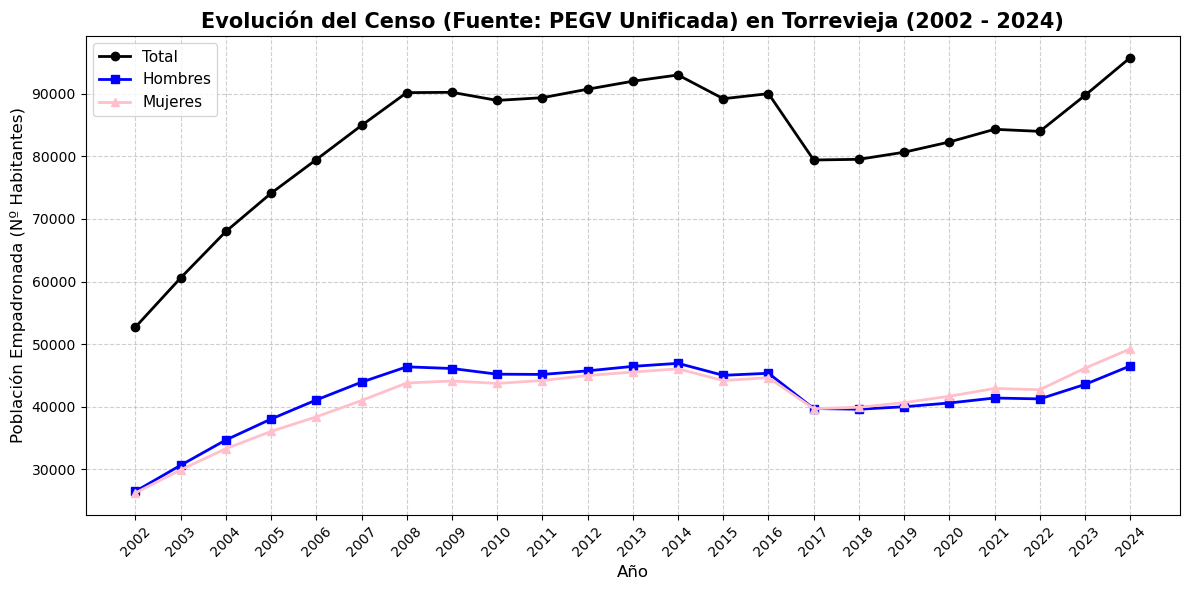

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# =========================================================================
# 1. LECTURA DE LOS 3 ARCHIVOS
# =========================================================================

# Usamos encoding 'latin1' (o 'utf-8' si ves caracteres raros en "años")
df_pegv_1 = pd.read_csv(r'C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES\censo_2002_2012_pegv.csv', sep=';', encoding='latin1')
df_pegv_2 = pd.read_csv(r'C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES\censo_2013_2020_pegv.csv', sep=';', encoding='latin1')
df_pegv_3 = pd.read_csv(r'C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES\censo_2021_2023_pegv.csv', sep=';', encoding='latin1')

# =========================================================================
# 2. EDA INDIVIDUAL (ESTUDIO POR SEPARADO)
# =========================================================================

def hacer_eda_basico(df, nombre_df):
    """Función auxiliar para no repetir código al imprimir el EDA de cada CSV"""
    print(f"\n{'='*50}")
    print(f" EDA DEL DATASET: {nombre_df}")
    print(f"{'='*50}")
    
    print("\n1. Nombre de las columnas:")
    print(df.columns.tolist())
    
    print("\n2. Tipos de datos y nulos:")
    # Para capturar el .info() que normalmente se imprime directo
    df.info()
    
    print("\n3. Primeras 3 filas:")
    display(df.head(3))

# Ejecutamos el EDA para cada uno
hacer_eda_basico(df_pegv_1, "CENSO 2002-2012")
hacer_eda_basico(df_pegv_2, "CENSO 2013-2020")
hacer_eda_basico(df_pegv_3, "CENSO 2021-2023")

print("\n!!! CONCLUSIÓN DEL EDA INDIVIDUAL !!!")
print("-> Los CSV 1 y 2 tienen la columna 'Edad'.")
print("-> El CSV 3 tiene la columna 'Edad (grupos quinquenales)'.")
print("-> Para poder unirlos, PRIMERO debemos renombrar esa columna del CSV 3.\n")


# =========================================================================
# 3. ARMONIZACIÓN Y UNIÓN DE LOS CSV
# =========================================================================

# Renombramos la columna del 3er CSV para que coincida exactamente con los otros dos
if 'Edad (grupos quinquenales)' in df_pegv_3.columns:
    df_pegv_3 = df_pegv_3.rename(columns={'Edad (grupos quinquenales)': 'Edad'})

# Juntamos los 3 archivos en un solo DataFrame
df_pegv = pd.concat([df_pegv_1, df_pegv_2, df_pegv_3], ignore_index=True)

# -------------------------------------------------------------------------
# EXPLICACIÓN DE LA SOLUCIÓN A LOS OUTLIERS:
# Al hacer el concat, los años 2012 y 2021 se duplicaron porque los CSV 
# originales compartían esos años en sus extremos (se solapaban).
# Si no los borramos, al sumar los habitantes salen 180.000 (el doble).
# Usamos drop_duplicates para buscar filas exactas y quedarnos solo con una.
# -------------------------------------------------------------------------
df_pegv = df_pegv.drop_duplicates(subset=['Periodo', 'Municipios', 'Sexo', 'Edad'], keep='last')

# Guardamos el archivo unificado (AHORA SÍ, LIMPIO Y SIN OUTLIERS) para futuros usos
df_pegv.to_csv(r'C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS MODIFICADOS\censo_pegv_unificado.csv', index=False, sep=';', encoding='utf-8-sig')
print("¡Fusión completada! Archivo 'censo_pegv_unificado.csv' limpio de duplicados y creado con éxito.\n")


# =========================================================================
# 4. LIMPIEZA Y TRANSFORMACIÓN DEL DATASET UNIDO
# =========================================================================

# 1. La PEGV nos da datos en Enero y en Julio. Nos quedamos solo con la foto de "1 de enero"
df_enero = df_pegv[df_pegv['Periodo'].str.contains('1 de enero', na=False)].copy()

# 2. Extraemos solo el número del año (ej: de "1 de enero de 2012" sacamos "2012")
df_enero['Año'] = df_enero['Periodo'].str.extract(r'(\d{4})').astype(int)

# 3. MUY IMPORTANTE: Filtramos filas que sean la suma de las edades (si las hay) 
# para no sumar a la gente dos veces.
df_edades = df_enero[df_enero['Edad'] != 'Total']

# 4. AGRUPAMOS: Por cada Año y cada Sexo, sumamos los valores de todas las franjas de edad
df_censo = df_edades.groupby(['Año', 'Sexo'])['Valor'].sum().reset_index()

# 5. La PEGV llama al total "Ambos sexos". Lo cambiamos a "Total" para que coincida con el estilo del INE
df_censo['Sexo'] = df_censo['Sexo'].replace({'Ambos sexos': 'Total'})


# =========================================================================
# 5. PREPARACIÓN Y CREACIÓN DE LA GRÁFICA
# =========================================================================

# Dividimos en 3 DataFrames para graficar cada línea
df_total = df_censo[df_censo['Sexo'] == 'Total']
df_hombres = df_censo[df_censo['Sexo'] == 'Hombres']
df_mujeres = df_censo[df_censo['Sexo'] == 'Mujeres']

plt.figure(figsize=(12, 6))

# Trazamos las líneas con los colores solicitados
plt.plot(df_total['Año'], df_total['Valor'], color='black', label='Total', marker='o', linewidth=2)
plt.plot(df_hombres['Año'], df_hombres['Valor'], color='blue', label='Hombres', marker='s', linewidth=2)
plt.plot(df_mujeres['Año'], df_mujeres['Valor'], color='pink', label='Mujeres', marker='^', linewidth=2)

# Títulos y diseño
plt.title('Evolución del Censo (Fuente: PEGV Unificada) en Torrevieja (2002 - 2024)', fontsize=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Población Empadronada (Nº Habitantes)', fontsize=12)

# Configurar el eje X para que muestre todos los años inclinados 45 grados
plt.xticks(df_total['Año'], rotation=45)

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Mostrar la gráfica
plt.show()

=== TABLA DE DIFERENCIAS (INE vs PEGV) ===
 Año  Total_INE  Total_PEGV  Diferencia (INE - PEGV)
2002      69763       52712                    17051
2003      77943       60572                    17371
2004      75530       67988                     7542
2005      84348       74095                    10253
2006      92034       79468                    12566
2007      94006       84921                     9085
2008     101381       90164                    11217
2009     101792       90216                    11576
2010     101091       88925                    12166
2011     102136       89353                    12783
2012     103720       90713                    13007
2013     105205       91990                    13215
2014      91415       92987                    -1572
2015      88447       89194                     -747
2016      84213       90001                    -5788
2017      83252       79405                     3847
2018      82599       79517                     3082
201

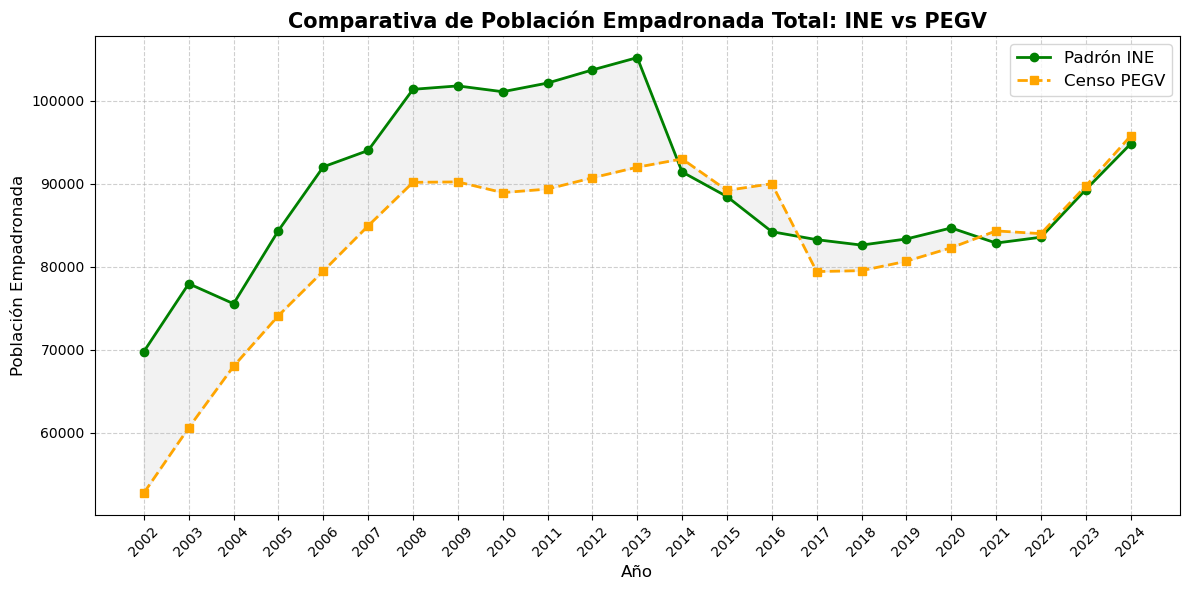

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================================
# 1. RUTAS DE TUS ARCHIVOS MODIFICADOS (YA LIMPIOS)
# =========================================================================
ruta_ine = r'C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS MODIFICADOS\censo_ine_limpio.csv'
ruta_pegv = r'C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS MODIFICADOS\censo_pegv_unificado.csv'

# =========================================================================
# 2. CARGA Y PREPARACIÓN DEL INE LIMPIO
# =========================================================================
# Leemos el archivo limpio.
try:
    df_ine = pd.read_csv(ruta_ine, sep=';', encoding='utf-8-sig')
except UnicodeDecodeError:
    df_ine = pd.read_csv(ruta_ine, sep=';', encoding='latin1')

# Homogeneizamos el nombre de la columna del año por si se llama 'Periodo'
if 'Periodo' in df_ine.columns:
    df_ine = df_ine.rename(columns={'Periodo': 'Año'})

# Filtramos solo el "Total" si aún existe la columna Sexo
if 'Sexo' in df_ine.columns:
    df_ine_total = df_ine[df_ine['Sexo'] == 'Total'].copy()
else:
    df_ine_total = df_ine.copy()

# Nos quedamos estrictamente con Año y Total para el cruce
df_ine_total = df_ine_total[['Año', 'Total']].rename(columns={'Total': 'Total_INE'})


# =========================================================================
# 3. CARGA Y PREPARACIÓN DE LA PEGV UNIFICADA
# =========================================================================
# ¡Cargamos el CSV que ya guardamos completamente limpio de duplicados!
df_pegv = pd.read_csv(ruta_pegv, sep=';', encoding='utf-8-sig')

# Filtramos por "1 de enero"
df_enero = df_pegv[df_pegv['Periodo'].str.contains('1 de enero', na=False)].copy()

# Extraemos el Año como número entero
df_enero['Año'] = df_enero['Periodo'].str.extract(r'(\d{4})').astype(int)

# Quitamos la etiqueta "Total" de edades para no duplicar habitantes y agrupamos
df_edades = df_enero[df_enero['Edad'] != 'Total']
df_censo_pegv = df_edades.groupby(['Año', 'Sexo'])['Valor'].sum().reset_index()

# Nos quedamos con "Ambos sexos", que es el equivalente a Total en la PEGV
df_pegv_total = df_censo_pegv[df_censo_pegv['Sexo'] == 'Ambos sexos'][['Año', 'Valor']].rename(columns={'Valor': 'Total_PEGV'})


# =========================================================================
# 4. CRUCE (MERGE) DE AMBAS FUENTES
# =========================================================================
# Unimos basándonos en el "Año" (inner join para quedarnos con los años comunes)
df_comparativa = pd.merge(df_ine_total, df_pegv_total, on='Año', how='inner')

# Calculamos la diferencia matemática
df_comparativa['Diferencia (INE - PEGV)'] = df_comparativa['Total_INE'] - df_comparativa['Total_PEGV']

print("=== TABLA DE DIFERENCIAS (INE vs PEGV) ===")
print(df_comparativa.to_string(index=False))


# =========================================================================
# 5. CREACIÓN DE LA GRÁFICA COMPARATIVA
# =========================================================================
plt.figure(figsize=(12, 6))

# Línea del INE (Verde)
plt.plot(df_comparativa['Año'], df_comparativa['Total_INE'], label='Padrón INE', marker='o', color='green', linewidth=2)

# Línea de la PEGV (Naranja y discontinua)
plt.plot(df_comparativa['Año'], df_comparativa['Total_PEGV'], label='Censo PEGV', marker='s', color='orange', linewidth=2, linestyle='--')

# Sombreado gris entre las dos líneas para destacar visualmente la diferencia
plt.fill_between(df_comparativa['Año'], df_comparativa['Total_INE'], df_comparativa['Total_PEGV'], color='gray', alpha=0.1)

# Diseño de la gráfica
plt.title('Comparativa de Población Empadronada Total: INE vs PEGV', fontsize=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Población Empadronada', fontsize=12)
plt.xticks(df_comparativa['Año'], rotation=45)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Mostrar la gráfica
plt.show()

#### B. CONSUMO DE ENERGÍA ELÉCTRICA Y USO DE LA VIVIENDA

##### 1. Identificación y origen

Para aproximar la capacidad de alojamiento no hotelero y dimensionar el volumen de población flotante vinculada a segundas residencias, se ha recurrido a una fuente estadística innovadora basada en rastros de consumo indirecto:

* **Instituto Nacional de Estadística (INE) - Censo de Población y Viviendas:** Se ha descargado el dataset relativo a la clasificación de las viviendas según su consumo eléctrico para el año 2021 (`viviendas_por_consumo_eléctrico_2021_ine.csv`). Esta estadística experimental del INE cruza los contadores eléctricos con el catastro para determinar qué casas están realmente habitadas, cuáles son vacacionales y cuáles están vacías. Los datos se pueden encontrar en: [Estadística experimental del INE](https://www.ine.es/jaxi/Tabla.htm?tpx=59531&L=0)

##### 2. Estado inicial y evaluación de calidad

A diferencia de los datos padronales, este conjunto de datos representa una "foto fija" o corte transversal correspondiente a un único año (2021). En su estado crudo (*raw data*), el archivo presenta las siguientes características:

* **Estructura jerárquica espacial:** Contiene columnas redundantes para el análisis local, ya que desglosa el ámbito Nacional, la Comunidad Autónoma, la Provincia y el Municipio.
* **Variable categórica mixta:** La columna de `Consumo eléctrico` mezcla conceptos diferentes. Por un lado, ofrece agregados generales (Ej. "Viviendas totales", "Viviendas vacías", "Viviendas de uso esporádico") y, por otro, desglosa estos mismos grupos en subcategorías muy específicas basadas en tramos de kilovatios-hora (Ej. "Viviendas con consumo entre 751 y 1.000 kwh").
* **Métricas combinadas:** El campo numérico `Total` agrupa tanto el conteo de viviendas como una métrica estadística descriptiva ("Mediana consumo anual"), lo que exige un filtrado previo para evitar inconsistencias en las sumas.

##### 3. Limpieza y transformación (Data Wrangling)

Para preparar este dataset de cara a su posterior análisis, se han aplicado los siguientes procedimientos:

* **Filtrado espacial y simplificación de columnas:** Se han eliminado las columnas referentes a demarcaciones territoriales superiores (España, Comunitat Valenciana, Alicante) para conservar únicamente el identificador del municipio y la variable de consumo.
* **Conversión de tipos de datos:** Al igual que ocurría con el censo del INE, la columna de valores absolutos utilizaba el punto (`.`) como separador de miles, forzando su lectura original como formato decimal o texto. Se ha aplicado una conversión a números enteros.
* **Segmentación de variables:** Se han aislado las métricas descriptivas (como la mediana de consumo) y se han categorizado las viviendas en grupos macro (Totales, Vacías, Uso esporádico, Bajo consumo) para evitar duplicidades al sumar los sub-tramos de kWh.

##### 4. Integración

Este dataset es una pieza clave para el cálculo de la **capacidad de carga** de Torrevieja. Al identificar cuántas viviendas son de "uso esporádico" (típicamente segunda residencia turística) o están "vacías", podemos estimar el tope máximo de población flotante que la ciudad puede absorber en momentos de máxima afluencia (por ejemplo, agosto). Esta variable se cruzará metodológicamente con el parque total de viviendas y el tamaño medio del hogar para modelar el techo demográfico efectivo del municipio.



 EDA DEL DATASET: VIVIENDAS POR CONSUMO ELÉCTRICO (2021)

1. Nombre de las columnas:
['Total Nacional', 'Comunidades y Ciudades Autónomas', 'Provincias', 'Municipios', 'Consumo eléctrico', 'Total']

2. Tipos de datos y valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Total Nacional                    18 non-null     object
 1   Comunidades y Ciudades Autónomas  18 non-null     object
 2   Provincias                        18 non-null     object
 3   Municipios                        18 non-null     object
 4   Consumo eléctrico                 18 non-null     object
 5   Total                             18 non-null     int64 
dtypes: int64(1), object(5)
memory usage: 996.0+ bytes

3. Primeras 5 filas del dataset:


,Total Nacional,Comunidades y Ciudades Autónomas,Provincias,Municipios,Consumo eléctrico,Total
0,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas totales,122736
1,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas vacías,30546
2,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Mediana consumo anual,1425
3,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas con bajo consumo,14988
4,Total Nacional,10 Comunitat Valenciana,03 Alicante/Alacant,03133 Torrevieja,Viviendas de uso esporádico,23513



4. Categorías únicas en 'Consumo eléctrico':
  - Viviendas totales
  - Viviendas vacías
  - Mediana consumo anual
  - Viviendas con bajo consumo
  - Viviendas de uso esporádico
  - Viviendas de uso esporádico (entre 251 y 500 kwh)
  - Viviendas de uso esporádico (entre 501 y 750 kwh)
  - Viviendas con consumo entre 751 y 1.000 kwh
  - Viviendas con consumo entre 1.001 y 2.000 kwh
  - Viviendas con consumo entre 2.001 y 3.000 kwh
  - Viviendas con consumo entre 3.001 y 4.000 kwh
  - Viviendas con consumo entre 4.001 y 5.000 kwh
  - Viviendas con consumo entre 5.001 y 6.000 kwh
  - Viviendas con consumo entre 6.001 y 7.000 kwh
  - Viviendas con consumo entre 7.001 y 8.000 kwh
  - Viviendas con consumo entre 8.001 y 9.000 kwh
  - Viviendas con consumo entre 9.001 y 10.000 kwh
  - Viviendas con consumo mayor de 10.000 kwh

-> DATO CURIOSO: La mediana de consumo anual en Torrevieja es de 1425 kWh.


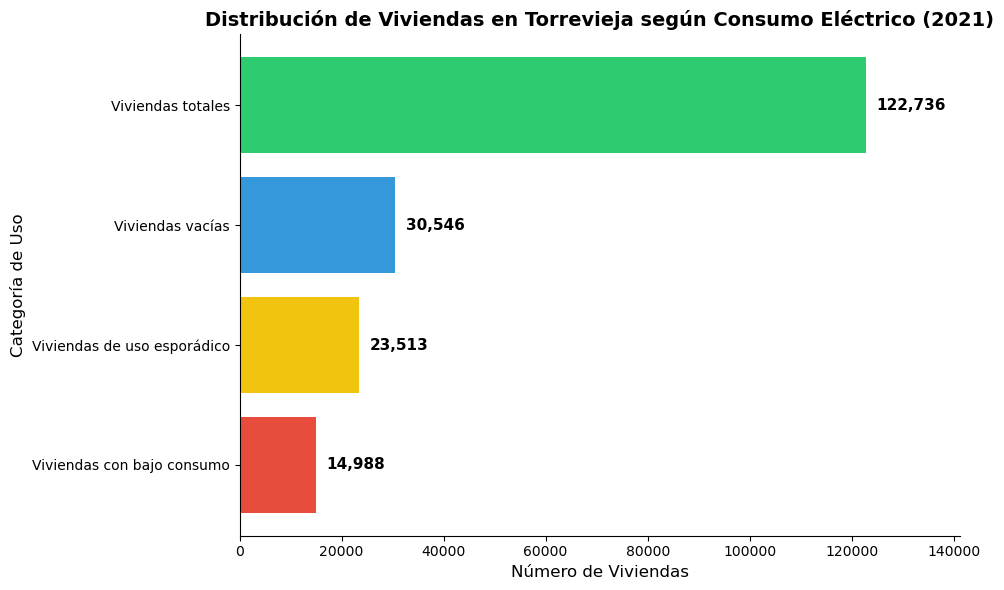

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# =========================================================================
# 1. CARGA DEL DATASET
# =========================================================================
# Ajusta la ruta a tu carpeta de trabajo
ruta_consumo = r'C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES\viviendas_por_consumo_eléctrico_2021_ine.csv'

# Leemos el CSV. Usamos sep=';' y miles='.' para que lea bien los números como 122.736
df_consumo = pd.read_csv(ruta_consumo, sep=';', encoding='latin1', thousands='.')

# =========================================================================
# 2. EDA (ANÁLISIS EXPLORATORIO DE DATOS)
# =========================================================================
print(f"{'='*50}")
print(" EDA DEL DATASET: VIVIENDAS POR CONSUMO ELÉCTRICO (2021)")
print(f"{'='*50}")

print("\n1. Nombre de las columnas:")
print(df_consumo.columns.tolist())

print("\n2. Tipos de datos y valores nulos:")
df_consumo.info()

print("\n3. Primeras 5 filas del dataset:")
display(df_consumo.head())

print("\n4. Categorías únicas en 'Consumo eléctrico':")
categorias = df_consumo['Consumo eléctrico'].unique()
for cat in categorias:
    print(f"  - {cat}")

# =========================================================================
# 3. LIMPIEZA BÁSICA Y PREPARACIÓN PARA VISUALIZACIÓN
# =========================================================================
# Nos quedamos solo con las columnas que aportan valor
df_limpio = df_consumo[['Consumo eléctrico', 'Total']].copy()

# Hay un valor que no es un conteo de viviendas, sino la "Mediana consumo anual"
# Lo extraemos para no mezclarlo en las gráficas
mediana_consumo = df_limpio[df_limpio['Consumo eléctrico'] == 'Mediana consumo anual']['Total'].values[0]
print(f"\n-> DATO CURIOSO: La mediana de consumo anual en Torrevieja es de {mediana_consumo} kWh.")

# Filtramos las categorías MACRO (evitamos los subtramos de kWh para no duplicar datos)
categorias_macro = [
    'Viviendas totales', 
    'Viviendas vacías', 
    'Viviendas con bajo consumo', 
    'Viviendas de uso esporádico'
]

df_macro = df_limpio[df_limpio['Consumo eléctrico'].isin(categorias_macro)].copy()

# Ordenamos de mayor a menor para que la gráfica quede bonita
df_macro = df_macro.sort_values('Total', ascending=True)

# =========================================================================
# 4. VISUALIZACIÓN DE LOS DATOS
# =========================================================================
plt.figure(figsize=(10, 6))

# Gráfico de barras horizontales
barras = plt.barh(df_macro['Consumo eléctrico'], df_macro['Total'], color=['#e74c3c', '#f1c40f', '#3498db', '#2ecc71'])

# Añadimos las etiquetas de datos justo al lado de cada barra
for barra in barras:
    ancho = barra.get_width()
    plt.text(ancho + 2000, barra.get_y() + barra.get_height()/2, 
             f'{int(ancho):,}', 
             va='center', fontsize=11, fontweight='bold')

# Diseño de la gráfica
plt.title('Distribución de Viviendas en Torrevieja según Consumo Eléctrico (2021)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Viviendas', fontsize=12)
plt.ylabel('Categoría de Uso', fontsize=12)

# Expandimos un poco el límite X para que quepan los textos de los números
plt.xlim(0, df_macro['Total'].max() * 1.15)

# Ocultar bordes innecesarios
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### C. BIG DATA DE MOVILIDAD: DISPOSITIVOS MÓVILES (INE)

##### 1. Identificación y origen

Para cuantificar de manera empírica la **Población Flotante** (turistas, visitantes y residentes no empadronados), se ha utilizado la estadística experimental del INE basada en la telefonía móvil. Esta fuente analiza el posicionamiento de las tarjetas SIM conectadas a las antenas del municipio, ofreciendo un conteo real de personas presentes.
Se han descargado los datos de tres grandes bloques, que cubren el periodo 2019-2026:
* **Turismo Receptor:** Dispositivos móviles extranjeros (roaming) detectados en Torrevieja.
* **Turismo Interno Interprovincial:** Dispositivos móviles españoles (de otras provincias) detectados en Torrevieja.
* **Turismo Emisor:** Dispositivos de residentes en Torrevieja que han viajado a otros destinos (para poder restar a los empadronados que están temporalmente ausentes).

Los datos se pueden consultar en: [Medición del turismo a partir de teléfonos móviles (INE)](https://www.ine.es/experimental/turismo_moviles/experimental_turismo_moviles.htm)

##### 2. Estado inicial y evaluación de calidad

Al analizar los archivos originales descargados (*raw data*), nos encontramos ante un reto de volumen y fragmentación de datos significativo:
* **Fragmentación extrema:** La información no se proporciona en un único archivo, sino que está dividida en decenas de libros de Excel (uno por año y tipo de turismo).
* **Estructura en pestañas:** Cada libro de Excel contiene múltiples hojas (una por cada mes del año), lo que dificulta la lectura programática estándar.
* **Volumen masivo (Ruido geográfico):** Los archivos contienen la matriz de movilidad de todos los municipios de España. Al escanear la estructura, se detectó que el total de registros superaba los **9,4 millones de filas** combinadas.

##### 3. Limpieza y transformación (Data Wrangling)

Para hacer manejable esta ingente cantidad de información y extraer únicamente el valor útil para el municipio, se diseñó un algoritmo iterativo de filtrado automatizado que ejecuta los siguientes pasos por cada carpeta:

1. **Lectura profunda:** El algoritmo abre cada archivo Excel, detecta automáticamente el número de hojas (meses) e itera sobre ellas, leyendo la matriz completa en memoria.
2. **Creación de variables temporales:** Se ha extraído el año desde el nombre del archivo y el mes desde el nombre de la pestaña, creando dos nuevas columnas (`año`, `mes_hoja`) para no perder la trazabilidad temporal.
3. **Filtrado espacial agresivo:** De cada hoja leída, el algoritmo busca la columna correspondiente (origen o destino según el caso) y extrae *únicamente* las filas donde el valor es "Torrevieja".
4. **Armonización de columnas:** Tras la concatenación de las hojas filtradas, se estandarizaron los nombres de las cabeceras (conversión a minúsculas y sustitución de espacios por guiones bajos) para evitar errores de sintaxis en el análisis posterior.

##### 4. Integración y resultados

El proceso de filtrado redujo drásticamente el volumen de datos de millones de registros a unos pocos miles (reducción superior al 99.7% del ruido), aislando la huella de movilidad exacta del municipio.

* **Turismo Receptor:** De 2,2 millones de filas analizadas, se extrajeron **3.411 registros** de extranjeros en Torrevieja.
* **Turismo Interno:** De 5,7 millones de filas, se aislaron **14.453 registros** de turistas nacionales.
* **Turismo Emisor:** De 1,4 millones de filas, se obtuvieron **1.813 registros** de residentes de Torrevieja viajando fuera.

Para la posterior estimación de la **Población Flotante**, se ha creado un *dataset* maestro combinando las entradas (Receptor + Interno), que será cruzado mes a mes con la base del censo empadronado.

In [ ]:
import pandas as pd
import os
import warnings

# Desactivamos avisos estéticos de Excel
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

# =========================================================================
# 1. DEFINICIÓN DE RUTAS
# =========================================================================
# (Ajusta estas rutas si tienes las carpetas en otro sitio)
RUTA_RECEPTOR = r"C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES\Turismo receptor - teléfonos móviles"
RUTA_EMISOR   = r"C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES\Turismo emisor - teléfonos móviles"
RUTA_INTERNO  = r"C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES\Turismo interno interprovincial - teléfonos móviles"

RUTA_SALIDA   = r"C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS MODIFICADOS"


# =========================================================================
# 2. FUNCIÓN PRINCIPAL DE EXTRACCIÓN Y FILTRADO
# =========================================================================
def procesar_telefonia_movil(ruta_carpeta, tipo):
    print(f"\n{'='*50}")
    print(f" 📂 PROCESANDO DATOS: TURISMO {tipo.upper()}")
    print(f"{'='*50}")
    
    dataframes = []
    total_filas = 0
    total_filas_filtradas = 0

    # Si la carpeta no existe, avisamos y salimos de la función
    if not os.path.exists(ruta_carpeta):
        print(f"❌ ERROR: No se encuentra la carpeta {ruta_carpeta}")
        return None

    # Recorremos todos los archivos de la carpeta
    for archivo in os.listdir(ruta_carpeta):
        if archivo.endswith(".xlsx"):
            ruta_archivo = os.path.join(ruta_carpeta, archivo)
            print(f"\n📄 Leyendo archivo: {archivo}")
            
            # Extraemos el año del nombre del archivo (buscamos un número de 4 cifras)
            import re
            match_ano = re.search(r'20\d{2}', archivo)
            año = int(match_ano.group()) if match_ano else None
            
            # Leemos TODAS las hojas del Excel
            try:
                hojas = pd.read_excel(ruta_archivo, sheet_name=None)
            except Exception as e:
                print(f"   ❌ Error al leer el archivo {archivo}: {e}")
                continue

            # Iteramos sobre cada hoja (mes) del archivo
            for nombre_hoja, df in hojas.items():
                filas_originales = len(df)
                total_filas += filas_originales

                # Añadimos variables temporales para no perder el rastro del mes/año
                df = df.copy()
                df["año"] = año
                df["mes_hoja"] = nombre_hoja

                # Limpiamos nombres de columnas temporalmente para evitar fallos por espacios
                df.columns = df.columns.str.lower().str.strip()

                # 🔴 FILTRO ESPACIAL SEGÚN EL TIPO DE TURISMO
                if tipo == "receptor":
                    # El extranjero viene HACIA Torrevieja
                    df_filtrado = df[df["mun_dest"] == "Torrevieja"]
                
                elif tipo == "emisor":
                    # El residente sale DESDE Torrevieja
                    df_filtrado = df[df["mun_orig"] == "Torrevieja"]
                
                elif tipo == "interno":
                    # El español viene HACIA Torrevieja
                    df_filtrado = df[df["dest"] == "Torrevieja"]
                
                else:
                    raise ValueError("Tipo no válido.")

                filas_filtradas = len(df_filtrado)
                total_filas_filtradas += filas_filtradas

                print(f"   ➤ Hoja: {nombre_hoja} | Analizadas: {filas_originales} → Torrevieja: {filas_filtradas}")

                if filas_filtradas > 0:
                    dataframes.append(df_filtrado)

    # Si hemos encontrado datos, los unimos todos en un solo DataFrame
    if dataframes:
        df_final = pd.concat(dataframes, ignore_index=True)
        # Limpieza definitiva de columnas (quitamos espacios y ponemos guiones bajos)
        df_final.columns = df_final.columns.str.lower().str.strip().str.replace(" ", "_")
        
        print("\n📊 RESUMEN FINAL DEL BLOQUE")
        print(f"   ➤ Filas totales leídas: {total_filas}")
        print(f"   ➤ Filas tras filtrado (Torrevieja): {total_filas_filtradas}")
        return df_final
    else:
        print("\n❌ No se extrajeron datos de esta carpeta.")
        return None

# =========================================================================
# 3. EJECUCIÓN DEL CÓDIGO Y CREACIÓN DE DATASETS
# =========================================================================

# Ejecutamos la función para los tres bloques
df_receptor = procesar_telefonia_movil(RUTA_RECEPTOR, "receptor")
df_emisor   = procesar_telefonia_movil(RUTA_EMISOR, "emisor")
df_interno  = procesar_telefonia_movil(RUTA_INTERNO, "interno")

# =========================================================================
# 4. GUARDADO DE RESULTADOS EN LA CARPETA 'MODIFICADOS'
# =========================================================================

print(f"\n{'='*50}")
print(" 💾 GUARDANDO DATASETS LIMPIOS Y CONSOLIDADOS")
print(f"{'='*50}")

# Creamos la carpeta de salida si no existe
if not os.path.exists(RUTA_SALIDA):
    os.makedirs(RUTA_SALIDA)
    print(f"📁 Carpeta creada: {RUTA_SALIDA}")
else:
    print(f"📁 La carpeta ya existe: {RUTA_SALIDA}\n")

# Función auxiliar para guardar en CSV
def guardar_dataset(df, nombre_archivo):
    if df is not None and not df.empty:
        ruta_completa = os.path.join(RUTA_SALIDA, nombre_archivo)
        df.to_csv(ruta_completa, index=False, sep=';', encoding='utf-8-sig')
        print(f"✅ Guardado: {nombre_archivo} (Filas: {len(df)})")
    else:
        print(f"❌ No se pudo guardar {nombre_archivo} (dataset vacío)")

# 1. Guardamos los tres archivos limpios individualmente
guardar_dataset(df_receptor, "receptor_torrevieja_limpio.csv")
guardar_dataset(df_emisor, "emisor_torrevieja_limpio.csv")
guardar_dataset(df_interno, "interno_torrevieja_limpio.csv")

# 2. Creamos la base de la "Población Flotante" sumando los que VIENEN (Receptor + Interno)
if df_receptor is not None and df_interno is not None:
    df_poblacion_flotante = pd.concat([df_receptor, df_interno], ignore_index=True)
    guardar_dataset(df_poblacion_flotante, "poblacion_flotante_base.csv")


 📂 PROCESANDO DATOS: TURISMO RECEPTOR

📄 Leyendo archivo: exp_tmov_receptor_mun_2019.xlsx
   ➤ Hoja: m07_2019 | Analizadas: 33317 → Torrevieja: 45
   ➤ Hoja: m08_2019 | Analizadas: 38143 → Torrevieja: 46
   ➤ Hoja: m09_2019 | Analizadas: 32390 → Torrevieja: 44
   ➤ Hoja: m10_2019 | Analizadas: 30784 → Torrevieja: 44
   ➤ Hoja: m11_2019 | Analizadas: 26930 → Torrevieja: 41
   ➤ Hoja: m12_2019 | Analizadas: 25955 → Torrevieja: 39

📄 Leyendo archivo: exp_tmov_receptor_mun_2020.xlsx
   ➤ Hoja: m01_2020 | Analizadas: 27009 → Torrevieja: 42
   ➤ Hoja: m02_2020 | Analizadas: 24978 → Torrevieja: 40
   ➤ Hoja: m03_2020 | Analizadas: 23005 → Torrevieja: 39
   ➤ Hoja: m04_2020 | Analizadas: 12726 → Torrevieja: 30
   ➤ Hoja: m05_2020 | Analizadas: 14187 → Torrevieja: 32
   ➤ Hoja: m06_2020 | Analizadas: 16838 → Torrevieja: 31
   ➤ Hoja: m07_2020 | Analizadas: 24266 → Torrevieja: 39
   ➤ Hoja: m08_2020 | Analizadas: 27131 → Torrevieja: 39
   ➤ Hoja: m09_2020 | Analizadas: 21992 → Torrevieja: 38
  

##### 5. Análisis Exploratorio y Visualización (Big Data de Movilidad)

Con los conjuntos de datos limpios y unificados, se han generado tres visualizaciones clave para comprender la dinámica de la **Población Flotante** en Torrevieja a lo largo de los años:

1. **Evolución Temporal (Estacionalidad y Efecto Pandemia):** El gráfico de líneas revela la curva estacional característica del destino. Se observa claramente el "efecto valle" de los inviernos y los inmensos picos de agosto, donde el turismo interno (nacional) dispara la presión demográfica. Es muy destacable la caída abrupta en los meses de marzo-junio de 2020 a causa del confinamiento por la COVID-19, y cómo la recuperación fue progresiva en 2021 y 2022. También se traza la línea del turismo *emisor* (residentes que viajan fuera) para poder calcular en el futuro el saldo demográfico neto.
2. **Top Provincias de Origen (Turismo Interno):** Un gráfico de barras horizontales que agrupa el histórico de visitantes nacionales, mostrando qué regiones de España alimentan principalmente a Torrevieja. Tradicionalmente, la ciudad ha sido el destino vacacional estrella para la capital de España (Madrid) y otras provincias de interior, así como de la propia comunidad y zonas colindantes.
3. **Top Países de Origen (Turismo Receptor):** Este gráfico aísla los países emisores de turismo internacional, filtrando los agregados continentales. Nos permite dimensionar con precisión la enorme influencia del mercado británico, de Europa central y de los países nórdicos, que no solo veranean, sino que frecuentemente extienden sus estancias en el municipio.

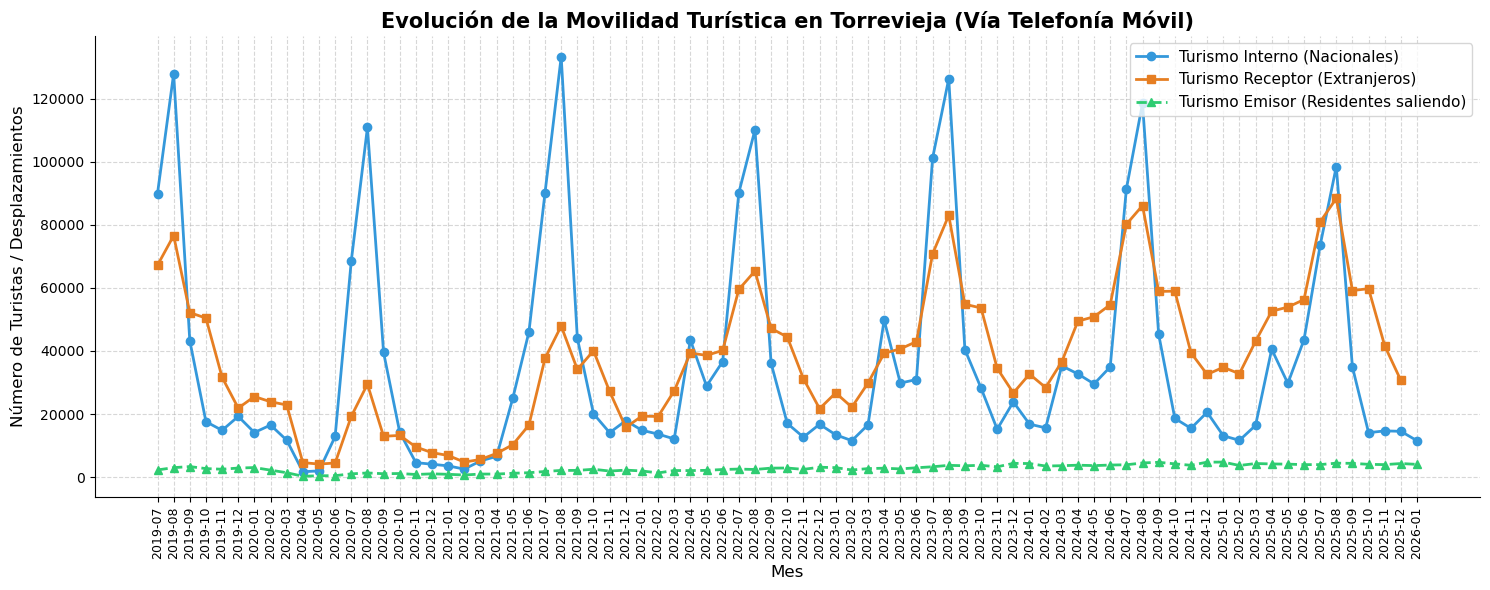

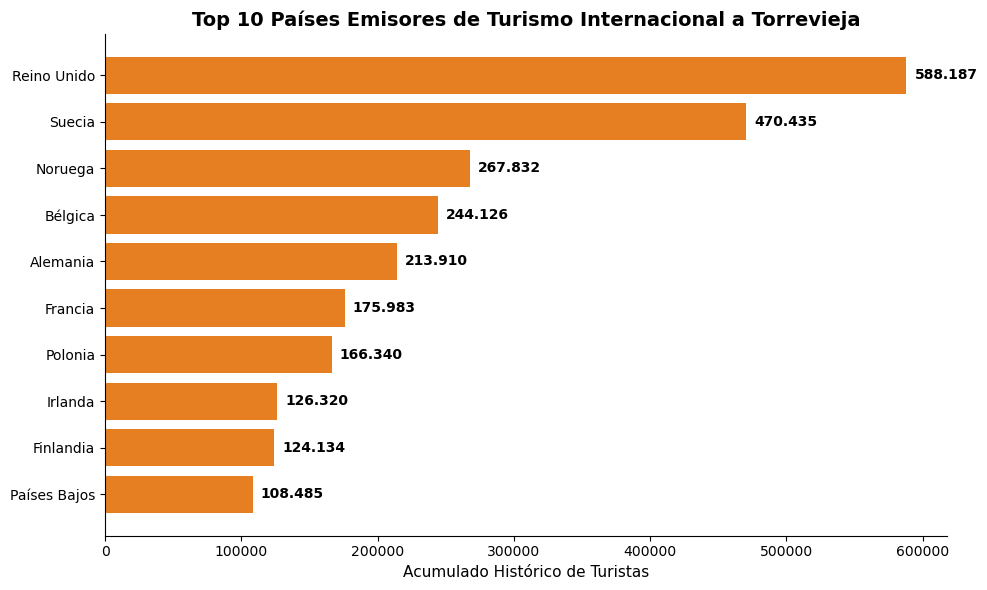

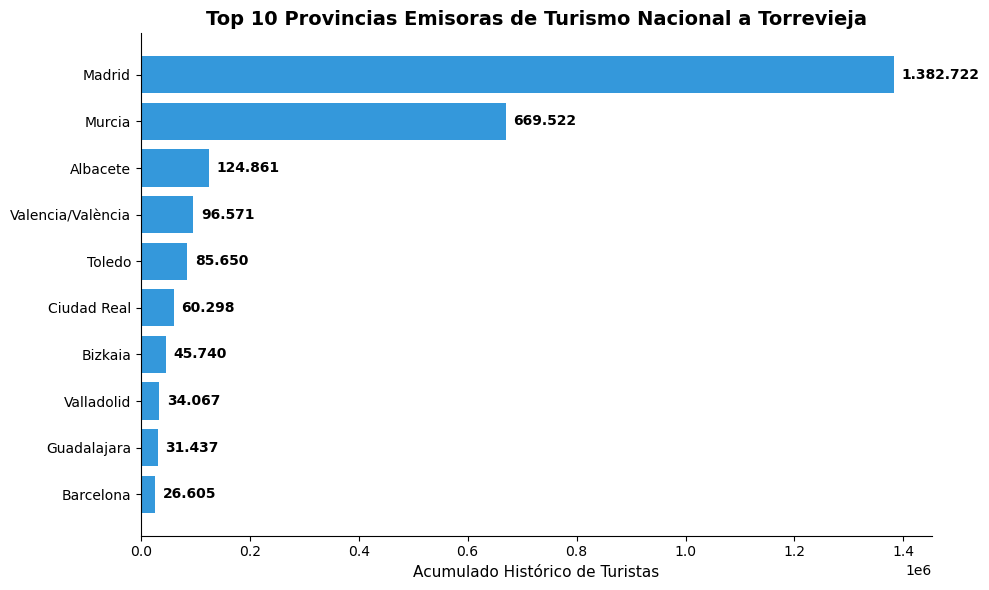

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# =========================================================================
# 1. RUTAS A LOS DATASETS YA LIMPIOS
# =========================================================================
RUTA_MODIFICADOS = r"C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS MODIFICADOS"

ruta_rec = os.path.join(RUTA_MODIFICADOS, "receptor_torrevieja_limpio.csv")
ruta_emi = os.path.join(RUTA_MODIFICADOS, "emisor_torrevieja_limpio.csv")
ruta_int = os.path.join(RUTA_MODIFICADOS, "interno_torrevieja_limpio.csv")

# Cargamos los datos limpios
df_receptor = pd.read_csv(ruta_rec, sep=';', encoding='utf-8-sig')
df_emisor   = pd.read_csv(ruta_emi, sep=';', encoding='utf-8-sig')
df_interno  = pd.read_csv(ruta_int, sep=';', encoding='utf-8-sig')


# =========================================================================
# 2. GRÁFICA 1: EVOLUCIÓN TEMPORAL (LÍNEAS)
# =========================================================================
# En Receptor y Emisor, el INE nos da filas de resumen llamadas "Total". Las filtramos para no sumar doble.
df_rec_evo = df_receptor[df_receptor['pais_orig'] == 'Total'].groupby('mes')['turistas'].sum().reset_index()
df_emi_evo = df_emisor[df_emisor['destino'] == 'Total'].groupby('mes')['turistas'].sum().reset_index()

# En el Interno NO hay fila de "Total", así que simplemente agrupamos y sumamos todos los turistas del mes
df_int_evo = df_interno.groupby('mes')['turistas'].sum().reset_index()

plt.figure(figsize=(15, 6))

plt.plot(df_int_evo['mes'], df_int_evo['turistas'], label='Turismo Interno (Nacionales)', color='#3498db', marker='o', linewidth=2)
plt.plot(df_rec_evo['mes'], df_rec_evo['turistas'], label='Turismo Receptor (Extranjeros)', color='#e67e22', marker='s', linewidth=2)
plt.plot(df_emi_evo['mes'], df_emi_evo['turistas'], label='Turismo Emisor (Residentes saliendo)', color='#2ecc71', marker='^', linewidth=2, linestyle='--')

plt.title('Evolución de la Movilidad Turística en Torrevieja (Vía Telefonía Móvil)', fontsize=15, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Número de Turistas / Desplazamientos', fontsize=12)

# Rotamos las etiquetas del eje X 90 grados para que quepan todos los meses
plt.xticks(rotation=90, fontsize=9)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Ocultar bordes innecesarios
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


# =========================================================================
# 3. GRÁFICA 2: TOP 10 PAÍSES DE ORIGEN (RECEPTOR)
# =========================================================================
# Excluimos las palabras que indican continentes o sumas globales para quedarnos solo con países reales
exclusiones = ['Total', 'Europa', 'Unión', 'América', 'Norte', 'Caribe', 'Sudamérica', 'Asia', 'África', 'Oceanía']
filtro_paises = ~df_receptor['pais_orig'].str.contains('|'.join(exclusiones), case=False, na=False)

# Agrupamos y sacamos el Top 10 histórico
top_paises = df_receptor[filtro_paises].groupby('pais_orig')['turistas'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
barras = plt.barh(top_paises.index, top_paises.values, color='#e67e22')

for b in barras:
    plt.text(b.get_width() + (top_paises.max() * 0.01), b.get_y() + b.get_height()/2, 
             f"{int(b.get_width()):,}".replace(',', '.'), 
             va='center', fontweight='bold')

plt.title('Top 10 Países Emisores de Turismo Internacional a Torrevieja', fontsize=14, fontweight='bold')
plt.xlabel('Acumulado Histórico de Turistas', fontsize=11)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


# =========================================================================
# 4. GRÁFICA 3: TOP 10 PROVINCIAS DE ORIGEN (INTERNO)
# =========================================================================
# Agrupamos los turistas de España por provincia y sacamos el Top 10 histórico
top_provincias = df_interno.groupby('prov_orig')['turistas'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
barras2 = plt.barh(top_provincias.index, top_provincias.values, color='#3498db')

for b in barras2:
    plt.text(b.get_width() + (top_provincias.max() * 0.01), b.get_y() + b.get_height()/2, 
             f"{int(b.get_width()):,}".replace(',', '.'), 
             va='center', fontweight='bold')

plt.title('Top 10 Provincias Emisoras de Turismo Nacional a Torrevieja', fontsize=14, fontweight='bold')
plt.xlabel('Acumulado Histórico de Turistas', fontsize=11)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### D. CAPACIDAD DE ALOJAMIENTO: PARQUE DE VIVIENDAS (1ª Y 2ª RESIDENCIA)

##### 1. Identificación y origen

Para calcular el volumen teórico de plazas de alojamiento no hotelero, es imperativo conocer el parque de viviendas del municipio y su tipología de uso. Esta variable es la que soporta la mayor carga de la población flotante turística (viviendas vacacionales y segundas residencias).

Se han extraído los datos del **Censo de Población y Viviendas del Instituto Nacional de Estadística (INE)**, correspondientes a las tres últimas oleadas censales. Las fuentes y métodos de obtención han sido los siguientes:

* **Censo 2021:** Descargado directamente en formato tabular (`tipo_vivienda_2021_ine.csv`). [Fuente INE](https://www.ine.es/jaxi/Tabla.htm?tpx=59526&L=0)
* **Censo 2011:** Descargado directamente en formato tabular (`tipo_vivienda_2011_ine.csv`). [Fuente INE](https://www.ine.es/jaxi/Tabla.htm?path=/t20/e244/viviendas/p06/l0/&file=11mun03.px&L=0)
* **Censo 2001:** Los datos de este ejercicio se consultaron en el portal histórico ([Fuente INE](https://www.ine.es/censo/es/listatablas.jsp?table=tablas/provincial/03/V1.html)). Debido a limitaciones de la plataforma institucional (que no permitía la exportación directa a CSV para esta tabla), los datos absolutos de Torrevieja se extrajeron manualmente y se empleó un *script* de inicialización en Python utilizando la librería `pandas` para generar y estructurar localmente el archivo `tipo_vivienda_2001_ine.csv`.

##### 2. Estado inicial y evaluación de calidad

Al explorar los conjuntos de datos en crudo, nos enfrentamos a un problema clásico de análisis histórico: **la evolución de las metodologías censales a lo largo de las décadas altera drásticamente los formatos**.

* **Censo de 2001:** Gracias a la extracción programática previa, presenta los datos en formato tabular horizontal estructurado, con columnas separadas para: *Total de viviendas, Principales, Secundarias y Vacías*.
* **Censo de 2011:** Utiliza una estructura vertical (varias filas), con nombres de categoría altamente específicos (Ej. `2.1 Total viviendas principales`) y presenta los valores numéricos como cadenas de texto con puntos para los miles.
* **Censo de 2021:** Modifica la categorización oficial. El INE deja de separar entre viviendas "Secundarias" y "Vacías", unificándolas en una macro-categoría denominada `Vivienda no principal`.

##### 3. Limpieza y transformación (Data Wrangling)

Para permitir el análisis longitudinal y la comparación cruzada entre décadas, se desarrolló un *script* que ejecuta los siguientes procesos:

1. **Lectura y transformación de tipos:** Se eliminaron los puntos de los miles en los archivos de 2011 y 2021, forzando la conversión de la columna `Total` a datos numéricos enteros (`int`).
2. **Armonización conceptual:** Para solventar el cambio de agrupación de 2021, se aplicó ingeniería de características (*feature engineering*) sobre los años anteriores. Se creó una nueva variable unificada llamada `Viviendas_No_Principales` calculada como la suma matemática de `Viviendas_Secundarias` + `Viviendas_Vacias` para los años 2001 y 2011.
3. **Consolidación:** Se extrajeron los valores individuales de cada archivo y se integraron en un nuevo *DataFrame* estructurado por año (`2001`, `2011`, `2021`), garantizando la coherencia estructural.

##### 4. Integración y resultados

El *dataset* consolidado (`evolucion_viviendas_2001_2021.csv`) revela la magnitud real de Torrevieja como destino residencial. El parque total de viviendas se ha incrementado de 102.363 unidades en 2001 a 122.736 en 2021.

Sin embargo, el dato clave para el modelo es la estabilización de las **Viviendas No Principales** (segundas residencias + vacías), que se sitúan en torno a **85.907 unidades en 2021**. Este volumen, multiplicado por el tamaño medio del hogar (índice de ocupación), representará el límite máximo (*capacidad de carga*) de la población flotante en la ciudad durante los picos de máxima afluencia estacional.

In [ ]:
import pandas as pd
import os

# 1. Datos extraídos
datos_2001 = {
    "Municipio": ["Torrevieja"],
    "Anyo_Censo": [2001],
    "Total_Viviendas": [102363],
    "Viviendas_Principales": [21565],
    "Viviendas_Secundarias": [61745],
    "Viviendas_Vacias": [18898]
}

# 2. Creamos el DataFrame
df_2001 = pd.DataFrame(datos_2001)

# 3. Definimos la ruta de la carpeta (Usamos 'r' al principio para evitar errores de barras)
ruta_carpeta = r"C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES"
nombre_archivo = "tipo_vivienda_2001_ine.csv"

# Unimos la carpeta y el nombre del archivo de forma segura
ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)

# 4. Verificamos si la carpeta existe, si no, la creamos
if not os.path.exists(ruta_carpeta):
    os.makedirs(ruta_carpeta)
    print(f"📁 Carpeta creada: {ruta_carpeta}")

# 5. Guardamos el CSV
df_2001.to_csv(ruta_completa, index=False, encoding="utf-8-sig")

print(f"✅ ¡Éxito! Archivo guardado en: {ruta_completa}")
display(df_2001)

✅ ¡Éxito! Archivo guardado en: C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES\tipo_vivienda_2001.csv


,Municipio,Anyo_Censo,Total_Viviendas,Viviendas_Principales,Viviendas_Secundarias,Viviendas_Vacias
0,Torrevieja,2001,102363,21565,61745,18898


=== PROCESANDO CENSO DE VIVIENDAS 2001 ===
2001 -> Totales: 102363 | Principales: 21565 | No Principales: 80643

=== PROCESANDO CENSO DE VIVIENDAS 2011 ===
2011 -> Totales: 122327 | Principales: 39855 | No Principales: 82472

=== PROCESANDO CENSO DE VIVIENDAS 2021 ===
2021 -> Totales: 122736 | Principales: 36829 | No Principales: 85907

✅ Dataset unificado guardado correctamente en:
C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS MODIFICADOS\evolucion_viviendas_2001_2021.csv


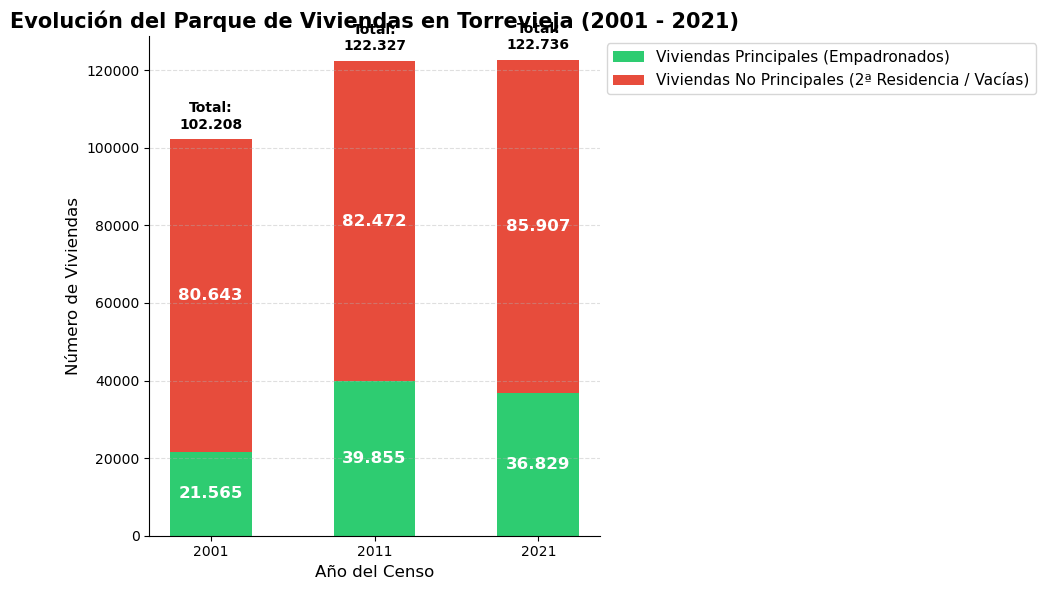

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# =========================================================================
# 1. RUTAS DE TUS ARCHIVOS ORIGINALES
# =========================================================================
ruta_2001 = r'C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES\tipo_vivienda_2001_ine.csv'
ruta_2011 = r'C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES\tipo_vivienda_2011_ine.csv'
ruta_2021 = r'C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES\tipo_vivienda_2021_ine.csv'

# Ruta donde guardaremos el dataset consolidado
RUTA_SALIDA = r'C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS MODIFICADOS'

# =========================================================================
# 2. EXTRACCIÓN Y LIMPIEZA (DATA WRANGLING)
# =========================================================================
print("=== PROCESANDO CENSO DE VIVIENDAS 2001 ===")
# 2001 viene separado por comas
df_2001 = pd.read_csv(ruta_2001, sep=',', encoding='latin1')
v_2001_tot = int(df_2001['Total_Viviendas'].values[0])
v_2001_prin = int(df_2001['Viviendas_Principales'].values[0])
v_2001_sec = int(df_2001['Viviendas_Secundarias'].values[0])
v_2001_vac = int(df_2001['Viviendas_Vacias'].values[0])
v_2001_noprin = v_2001_sec + v_2001_vac
print(f"2001 -> Totales: {v_2001_tot} | Principales: {v_2001_prin} | No Principales: {v_2001_noprin}")

print("\n=== PROCESANDO CENSO DE VIVIENDAS 2011 ===")
# 2011 viene separado por punto y coma, y con puntos en los miles. SOLUCIÓN: encoding='latin1'
df_2011 = pd.read_csv(ruta_2011, sep=';', encoding='latin1')
df_2011['Total'] = df_2011['Total'].astype(str).str.replace('.', '').astype(int)
v_2011_prin = df_2011.loc[df_2011['Tipo de vivienda'] == '2.1 Total viviendas principales', 'Total'].values[0]
v_2011_sec = df_2011.loc[df_2011['Tipo de vivienda'] == '2.21 Viviendas secundarias', 'Total'].values[0]
v_2011_vac = df_2011.loc[df_2011['Tipo de vivienda'] == '2.22 Viviendas vacias', 'Total'].values[0]
v_2011_tot = v_2011_prin + v_2011_sec + v_2011_vac
v_2011_noprin = v_2011_sec + v_2011_vac
print(f"2011 -> Totales: {v_2011_tot} | Principales: {v_2011_prin} | No Principales: {v_2011_noprin}")

print("\n=== PROCESANDO CENSO DE VIVIENDAS 2021 ===")
# 2021 también viene con punto y coma. SOLUCIÓN: encoding='latin1'
df_2021 = pd.read_csv(ruta_2021, sep=';', encoding='latin1')
df_2021['Total'] = df_2021['Total'].astype(str).str.replace('.', '').astype(int)
v_2021_tot = df_2021.loc[df_2021['Tipo de vivienda (principal o no)'] == 'Total', 'Total'].values[0]
v_2021_prin = df_2021.loc[df_2021['Tipo de vivienda (principal o no)'] == 'Vivienda principal', 'Total'].values[0]
v_2021_noprin = df_2021.loc[df_2021['Tipo de vivienda (principal o no)'] == 'Vivienda no principal', 'Total'].values[0]
print(f"2021 -> Totales: {v_2021_tot} | Principales: {v_2021_prin} | No Principales: {v_2021_noprin}")


# =========================================================================
# 3. CREACIÓN DEL DATASET UNIFICADO Y GUARDADO
# =========================================================================
# Juntamos los datos procesados en un único DataFrame limpio
df_viviendas = pd.DataFrame({
    'Año': [2001, 2011, 2021],
    'Total_Viviendas': [v_2001_tot, v_2011_tot, v_2021_tot],
    'Viviendas_Principales': [v_2001_prin, v_2011_prin, v_2021_prin],
    'Viviendas_No_Principales': [v_2001_noprin, v_2011_noprin, v_2021_noprin],
    'Viviendas_Secundarias': [v_2001_sec, v_2011_sec, None], # El censo 2021 ya no separa esto
    'Viviendas_Vacias': [v_2001_vac, v_2011_vac, None]       # El censo 2021 ya no separa esto
})

# Guardamos el dataset en la carpeta de modificados
if not os.path.exists(RUTA_SALIDA):
    os.makedirs(RUTA_SALIDA)

ruta_guardado = os.path.join(RUTA_SALIDA, "evolucion_viviendas_2001_2021.csv")
# Al guardar lo forzamos a utf-8-sig para que en el futuro no tengamos problemas en Excel o Python
df_viviendas.to_csv(ruta_guardado, index=False, sep=';', encoding='utf-8-sig')
print(f"\n✅ Dataset unificado guardado correctamente en:\n{ruta_guardado}")


# =========================================================================
# 4. VISUALIZACIÓN DE LA EVOLUCIÓN (GRÁFICA)
# =========================================================================
plt.figure(figsize=(10, 6))

años = df_viviendas['Año'].astype(str)
principales = df_viviendas['Viviendas_Principales']
no_principales = df_viviendas['Viviendas_No_Principales']

# Creamos un Gráfico de barras apiladas (Stacked Bar Chart)
bar1 = plt.bar(años, principales, label='Viviendas Principales (Empadronados)', color='#2ecc71', width=0.5)
bar2 = plt.bar(años, no_principales, bottom=principales, label='Viviendas No Principales (2ª Residencia / Vacías)', color='#e74c3c', width=0.5)

# Añadimos los números dentro de las barras inferiores (Principales)
for b in bar1:
    plt.text(b.get_x() + b.get_width()/2, b.get_height()/2, 
             f"{int(b.get_height()):,}".replace(',', '.'), 
             va='center', ha='center', color='white', fontweight='bold', fontsize=12)

# Añadimos los números dentro de las barras superiores (No Principales)
for b1, b2 in zip(bar1, bar2):
    plt.text(b2.get_x() + b2.get_width()/2, b1.get_height() + b2.get_height()/2, 
             f"{int(b2.get_height()):,}".replace(',', '.'), 
             va='center', ha='center', color='white', fontweight='bold', fontsize=12)

# Añadimos el número TOTAL encima de cada columna
for b1, b2 in zip(bar1, bar2):
    total_columna = b1.get_height() + b2.get_height()
    plt.text(b2.get_x() + b2.get_width()/2, total_columna + 2000, 
             f"Total:\n{int(total_columna):,}".replace(',', '.'), 
             va='bottom', ha='center', color='black', fontweight='bold', fontsize=10)

# Diseño final de la gráfica
plt.title('Evolución del Parque de Viviendas en Torrevieja (2001 - 2021)', fontsize=15, fontweight='bold')
plt.ylabel('Número de Viviendas', fontsize=12)
plt.xlabel('Año del Censo', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=11)

# Ocultamos la cuadrícula horizontal y los bordes
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

https://www.turisme.gva.es/opencms/opencms/turisme/es/contents/estadistiquesdeturisme/anuario/oferta_turistica/oferta_turistica_municipal_comarcal.html DENTRO DE ESTA PAGINA HAY VARIOS PDF DESDE 2000 HASTA 2022, EN LOS QUE PODEMOS ENCONTRAR LA INFORMACION DE CANTIDAD DE HOTELES, APARTAMENTOS TURISTICOS, HOSTALES, .... EN TORREVIEJA 

In [15]:
import os

RUTA_BASE = r'C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES'

print("=== MAPA COMPLETO DE CARPETAS Y ARCHIVOS ===\n")

# os.walk recorre el árbol de directorios de arriba a abajo
for raiz, directorios, archivos in os.walk(RUTA_BASE):
    # Calculamos el nivel de profundidad para hacer una indentación bonita
    nivel = raiz.replace(RUTA_BASE, '').count(os.sep)
    indentacion = ' ' * 4 * nivel
    
    # Imprimimos la carpeta actual
    nombre_carpeta = os.path.basename(raiz)
    if nombre_carpeta == "":
        nombre_carpeta = "DATASETS ORIGINALES (Carpeta Raíz)"
    print(f"{indentacion}📁 {nombre_carpeta}/")
    
    # Imprimimos los archivos dentro de esa carpeta
    sub_indent = ' ' * 4 * (nivel + 1)
    for archivo in archivos:
        print(f"{sub_indent}📄 {archivo}")

=== MAPA COMPLETO DE CARPETAS Y ARCHIVOS ===

📁 DATASETS ORIGINALES/
    📄 censo_1996_2025_ine.csv
    📄 censo_2002_2012_pegv.csv
    📄 censo_2013_2020_pegv.csv
    📄 censo_2021_2023_pegv.csv
    📄 tipo_vivienda_2001_ine.csv
    📄 tipo_vivienda_2011_ine.csv
    📄 tipo_vivienda_2021_ine.csv
    📄 viviendas_por_consumo_eléctrico_2021_ine.csv
    📁 Alojamientos/
        📄 Oferta2013-def.pdf
        📄 Oferta_2008-def.pdf
        📄 Oferta_2009_539_KB.pdf
        📄 Oferta_2010_definitiva.pdf
        📄 Oferta_2012-def.pdf
        📄 Oferta_2014-defi.pdf
        📄 Oferta_2015-def.pdf
        📄 Oferta_CV_2011.pdf
        📄 oferta_municipal_2000.pdf
        📄 oferta_municipal_2001.pdf
        📄 oferta_municipal_2002.pdf
        📄 oferta_municipal_2004.pdf
        📄 oferta_municipal_2005.pdf
        📄 oferta_municipal_2006.pdf
        📄 Oferta_muni_coma_2007.pdf
        📄 OTMC-2016.pdf
        📄 OTMC-2018c.pdf
        📄 OTMC_2017c.pdf
        📄 OTMC_2019c.pdf
        📄 OTMC_2020c.pdf
        📄 OTM

In [22]:
import pandas as pd
import os
import warnings

# Desactivamos avisos estéticos de Excel para que la lectura sea limpia
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

RUTA_BASE = r'C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES'

def escanear_estructura_completa(directorio):
    print("=== INICIANDO ESCÁNER DE ESTRUCTURAS DE DATOS ===\n")
    
    for raiz, dirs, archivos in os.walk(directorio):
        # Filtramos solo archivos de datos (csv o xlsx)
        archivos_datos = [f for f in archivos if f.endswith(('.csv', '.xlsx')) and not f.startswith('~$')]
        
        if not archivos_datos:
            continue
            
        # Tomamos el primer archivo de cada carpeta como muestra de la estructura
        archivo_muestra = archivos_datos[0]
        ruta_completa = os.path.join(raiz, archivo_muestra)
        nombre_carpeta = os.path.basename(raiz)
        
        print(f"📁 CARPETA: {nombre_carpeta}")
        print(f"📄 Archivo analizado: {archivo_muestra}")
        
        try:
            # Intentamos leerlo. Si es Excel, probamos primero sin saltar filas
            if archivo_muestra.endswith('.xlsx'):
                df_test = pd.read_excel(ruta_completa, sheet_name=0, nrows=10)
            else:
                df_test = pd.read_csv(ruta_completa, sep=';', encoding='latin1', nrows=10)
            
            # Comprobamos si las columnas son "Unnamed" (indicador de que hay basura arriba)
            unnamed_cols = [c for c in df_test.columns if 'Unnamed' in str(c)]
            
            if len(unnamed_cols) > len(df_test.columns) / 2:
                print("   ⚠️ ATENCIÓN: Esta estructura parece tener FILAS VACÍAS al principio.")
                print("   Columnas detectadas (sucias):", df_test.columns.tolist())
                
                # Intentamos detectar dónde empieza la tabla real buscando palabras clave
                # Leemos más filas para inspeccionar
                df_inspeccion = pd.read_excel(ruta_completa, sheet_name=0, header=None, nrows=15)
                for i, fila in df_inspeccion.iterrows():
                    fila_str = str(fila.values).lower()
                    if 'destino' in fila_str or 'origen' in fila_str or 'mes' in fila_str:
                        print(f"   💡 SUGERENCIA: La tabla real parece empezar en la fila {i}")
                        print(f"   Cabecera detectada en fila {i}: {fila.dropna().tolist()}")
                        break
            else:
                print("   ✅ Estructura limpia detectada.")
                print(f"   Columnas reales: {df_test.columns.tolist()}")
                
        except Exception as e:
            print(f"   ❌ Error al analizar: {e}")
        
        print("-" * 60)

escanear_estructura_completa(RUTA_BASE)

=== INICIANDO ESCÁNER DE ESTRUCTURAS DE DATOS ===

📁 CARPETA: DATASETS ORIGINALES
📄 Archivo analizado: censo_torrevieja_2003_2022.csv
   ✅ Estructura limpia detectada.
   Columnas reales: ['Sexo', 'Provincias', 'Municipios', 'Nacionalidad', 'Edad (grandes grupos)', 'Periodo', 'Total']
------------------------------------------------------------
📁 CARPETA: Turismo emisor - teléfonos móviles
📄 Archivo analizado: exp_tmov_emisor_mun_2019.xlsx
   ✅ Estructura limpia detectada.
   Columnas reales: ['mes', 'mun_orig_cod', 'mun_orig', 'destino_cod', 'destino', 'turistas', 'prov_orig_cod', 'prov_orig']
------------------------------------------------------------
📁 CARPETA: Turismo interno interprovincial - teléfonos móviles
📄 Archivo analizado: exp_tmov_interno_mun_2019.xlsx
   ✅ Estructura limpia detectada.
   Columnas reales: ['mes', 'mun_orig_cod', 'mun_orig', 'dest_cod', 'dest', 'turistas', 'prov_orig_cod', 'prov_orig', 'prov_dest_cod', 'prov_dest']
----------------------------------------

In [38]:
import pandas as pd
import os

def cargar_y_filtrar_tmov(ruta_carpeta, tipo):
    print(f"\n📂 Procesando carpeta: {ruta_carpeta}")
    print(f"🔎 Tipo de dataset: {tipo}")
    
    dataframes = []
    total_filas = 0
    total_filas_filtradas = 0

    for archivo in os.listdir(ruta_carpeta):
        if archivo.endswith(".xlsx"):
            ruta_archivo = os.path.join(ruta_carpeta, archivo)
            print(f"\n📄 Leyendo archivo: {archivo}")
            
            # Extraer año
            try:
                año = int(archivo.split("_")[-1].split(".")[0])
            except:
                print("⚠️ No se pudo extraer el año del nombre del archivo")
                año = None
            
            # Leer todas las hojas
            hojas = pd.read_excel(ruta_archivo, sheet_name=None)
            print(f"   ➤ Número de hojas encontradas: {len(hojas)}")

            for nombre_hoja, df in hojas.items():
                filas_originales = len(df)
                total_filas += filas_originales

                df = df.copy()
                
                # Añadir columnas temporales
                df["año"] = año
                df["mes_hoja"] = nombre_hoja

                # 🔴 FILTRO SEGÚN TIPO
                if tipo == "receptor":
                    df_filtrado = df[df["mun_dest"] == "Torrevieja"]
                
                elif tipo == "emisor":
                    df_filtrado = df[df["mun_orig"] == "Torrevieja"]
                
                elif tipo == "interno":
                    df_filtrado = df[df["dest"] == "Torrevieja"]
                
                else:
                    raise ValueError("Tipo no válido. Usa: receptor, emisor o interno")

                filas_filtradas = len(df_filtrado)
                total_filas_filtradas += filas_filtradas

                print(f"      📅 Hoja: {nombre_hoja} | Filas originales: {filas_originales} → Filtradas: {filas_filtradas}")

                if filas_filtradas > 0:
                    dataframes.append(df_filtrado)

    # Unir todo
    if dataframes:
        df_final = pd.concat(dataframes, ignore_index=True)
        print("\n✅ Unión completada correctamente")
    else:
        print("\n❌ No hay datos tras el filtrado")
        return None

    # Limpieza de columnas
    print("\n🧹 Limpiando nombres de columnas...")
    df_final.columns = df_final.columns.str.lower().str.strip().str.replace(" ", "_")

    # Resumen final
    print("\n📊 RESUMEN FINAL")
    print(f"   ➤ Filas totales leídas: {total_filas}")
    print(f"   ➤ Filas tras filtrado (Torrevieja): {total_filas_filtradas}")
    print(f"   ➤ Filas finales en dataset: {len(df_final)}")
    print(f"   ➤ Columnas: {list(df_final.columns)}")

    return df_final

In [40]:
# Rutas (ajusta a tu estructura)
ruta_receptor = r"C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES\Turismo receptor - teléfonos móviles"
ruta_emisor = r"C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES\Turismo emisor - teléfonos móviles"
ruta_interno = r"C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES\Turismo interno interprovincial - teléfonos móviles"

print("\n================ RECEPTOR ================")
df_receptor_torrevieja = cargar_y_filtrar_tmov(ruta_receptor, "receptor")

print("\n================ EMISOR ================")
df_emisor_torrevieja = cargar_y_filtrar_tmov(ruta_emisor, "emisor")

print("\n================ INTERNO ================")
df_interno_torrevieja = cargar_y_filtrar_tmov(ruta_interno, "interno")


================ RECEPTOR ================

📂 Procesando carpeta: C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS ORIGINALES\Turismo receptor - teléfonos móviles
🔎 Tipo de dataset: receptor

📄 Leyendo archivo: exp_tmov_receptor_mun_2019.xlsx
   ➤ Número de hojas encontradas: 6
      📅 Hoja: m07_2019 | Filas originales: 33317 → Filtradas: 45
      📅 Hoja: m08_2019 | Filas originales: 38143 → Filtradas: 46
      📅 Hoja: m09_2019 | Filas originales: 32390 → Filtradas: 44
      📅 Hoja: m10_2019 | Filas originales: 30784 → Filtradas: 44
      📅 Hoja: m11_2019 | Filas originales: 26930 → Filtradas: 41
      📅 Hoja: m12_2019 | Filas originales: 25955 → Filtradas: 39

📄 Leyendo archivo: exp_tmov_receptor_mun_2020.xlsx
   ➤ Número de hojas encontradas: 12
      📅 Hoja: m01_2020 | Filas originales: 27009 → Filtradas: 42
      📅 Hoja: m02_2020 | Filas originales: 24978 → Filtradas: 40
      📅 Hoja: m03_2020 | Fila

In [ ]:
# 📁 Crear carpeta si no existe
ruta_salida = r"C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS MODIFICADOS"

if not os.path.exists(ruta_salida):
    os.makedirs(ruta_salida)
    print(f"\n📁 Carpeta creada: {ruta_salida}")
else:
    print(f"\n📁 La carpeta ya existe: {ruta_salida}")


# 💾 Función para guardar datasets
def guardar_dataset(df, nombre_archivo):
    if df is not None:
        ruta_completa = os.path.join(ruta_salida, nombre_archivo)
        
        df.to_csv(ruta_completa, index=False)
        
        print(f"✅ Dataset guardado: {ruta_completa}")
        print(f"   ➤ Filas: {len(df)} | Columnas: {len(df.columns)}")
    else:
        print(f"❌ No se pudo guardar {nombre_archivo} (dataset vacío)")

#  Crear población flotante
df_poblacion_flotante = pd.concat([
    df_receptor_torrevieja,
    df_interno_torrevieja
], ignore_index=True)

#  Guardar
guardar_dataset(df_poblacion_flotante, "poblacion_flotante_torrevieja.csv")

# 💾 Guardar datasets
guardar_dataset(df_receptor_torrevieja, "receptor_torrevieja.csv")
guardar_dataset(df_emisor_torrevieja, "emisor_torrevieja.csv")
guardar_dataset(df_interno_torrevieja, "interno_torrevieja.csv")


📁 La carpeta ya existe: C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS MODIFICADOS
✅ Dataset guardado: C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS MODIFICADOS\poblacion_flotante_torrevieja.csv
   ➤ Filas: 17864 | Columnas: 16
✅ Dataset guardado: C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS MODIFICADOS\receptor_torrevieja.csv
   ➤ Filas: 3411 | Columnas: 10
✅ Dataset guardado: C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS MODIFICADOS\emisor_torrevieja.csv
   ➤ Filas: 1813 | Columnas: 10
✅ Dataset guardado: C:\Users\Usuario\Documents\MASTER EN CIENCIA DE DATOS UA\MINERIA DE DATOS\TRABAJO_3\Turismo Mineria Datos\DATASETS\RETO 1\DATASETS MODIFICADOS\int